# Evaluating an AI News Digest Pipeline
## Threshold Tuning, Embedding Analysis, and Source Quality

This notebook evaluates the ML pipeline behind a weekly AI news digest system that curates the top 10 stories from 12 RSS feeds. The pipeline uses OpenAI `text-embedding-3-small` embeddings for both deduplication (cosine similarity threshold = 0.85) and topic classification (5 categories, zero extra API cost by reusing dedup embeddings).

**Dataset:** 437 articles across 7 pipeline runs, 5 topic categories, 12 RSS sources.

We evaluate four aspects: (1) whether the dedup and relevance thresholds are well-calibrated, (2) whether the embedding-based topic assignments form coherent clusters, (3) which RSS sources deliver signal vs. noise, and (4) how the pipeline funnel behaves across runs.

In [1]:
import sqlite3, json, os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from dotenv import load_dotenv

load_dotenv(os.path.join(os.path.dirname(os.getcwd()), ".env"))
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 150

# Load articles and runs from SQLite
conn = sqlite3.connect("../data/digest.db")
df = pd.read_sql("SELECT * FROM articles", conn)
runs = pd.read_sql("SELECT * FROM digest_runs", conn)
conn.close()

runs["topics"] = runs["topics_json"].apply(json.loads)

# Load cached topic embeddings
topic_embeddings = np.load("../data/topic_embeddings.npy")
TOPIC_NAMES = ["nlp", "computer-vision", "llms", "robotics", "general-ai"]

print(f"{len(df)} articles, {len(runs)} runs, {df['topic'].nunique()} active topics")
print(f"Date range: {df['digest_date'].min()} to {df['digest_date'].max()}")
print(f"Topics: {df['topic'].value_counts().to_dict()}")

437 articles, 7 runs, 4 active topics
Date range: 2026-03-28 to 2026-04-02
Topics: {'general-ai': 290, 'llms': 110, 'computer-vision': 20, 'robotics': 17}


In [2]:
CACHE_PATH = "../data/article_embeddings.npy"

if os.path.exists(CACHE_PATH):
    article_embeddings = np.load(CACHE_PATH)
    print(f"Loaded cached embeddings: {article_embeddings.shape}")
else:
    from openai import OpenAI
    client = OpenAI()
    texts = (df["title"] + " " + df["summary"].fillna("")).tolist()
    
    all_embs = []
    for i in range(0, len(texts), 100):
        batch = texts[i:i+100]
        resp = client.embeddings.create(model="text-embedding-3-small", input=batch)
        all_embs.extend([e.embedding for e in resp.data])
        print(f"Embedded {min(i+100, len(texts))}/{len(texts)}")
    
    article_embeddings = np.array(all_embs)
    np.save(CACHE_PATH, article_embeddings)
    print(f"Saved embeddings: {article_embeddings.shape}")

Embedded 100/437
Embedded 200/437
Embedded 300/437
Embedded 400/437
Embedded 437/437
Saved embeddings: (437, 1536)


## 1. Threshold Tuning

The pipeline uses two cosine-similarity thresholds that control quality vs. coverage:
- **Deduplication (0.85):** Articles with similarity above this are considered duplicates
- **Relevance filter (0.20):** Articles whose best topic match falls below this are rejected as non-AI content

We sweep both to validate they sit at reasonable operating points.

In [3]:
# Compute full pairwise similarity matrix
sim_matrix = cosine_similarity(article_embeddings)

# Sweep dedup threshold using the exact greedy algorithm from the pipeline
thresholds = np.arange(0.70, 0.96, 0.01)
dedup_results = []

for t in thresholds:
    removed = set()
    for i in range(len(df)):
        if i in removed:
            continue
        for j in range(i + 1, len(df)):
            if j not in removed and sim_matrix[i][j] > t:
                removed.add(j)
    kept = len(df) - len(removed)
    dedup_results.append({"threshold": t, "articles_kept": kept,
                          "duplicates_removed": len(removed),
                          "dedup_rate": len(removed) / len(df) * 100})

dedup_df = pd.DataFrame(dedup_results)
print(f"At production threshold (0.85): {dedup_df[dedup_df['threshold'].round(2) == 0.85].iloc[0]['articles_kept']:.0f} articles kept")

At production threshold (0.85): 157 articles kept


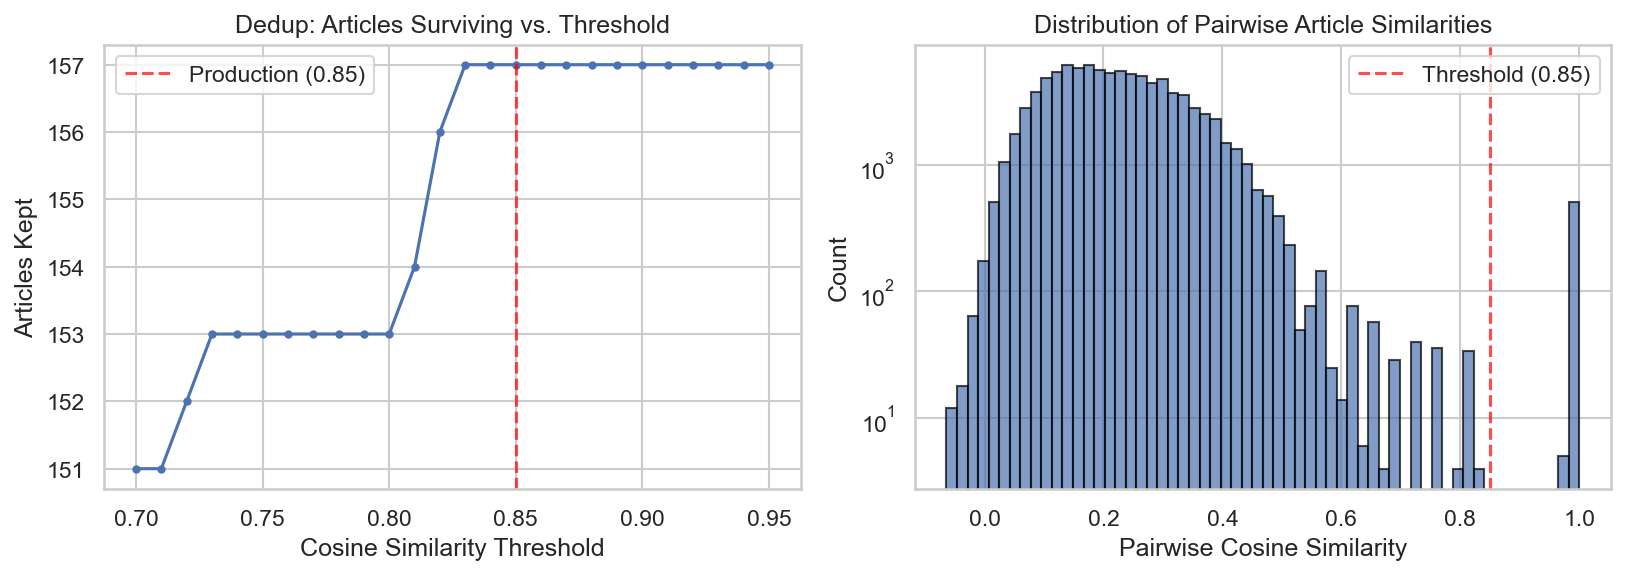

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Left: articles kept vs threshold
ax1.plot(dedup_df["threshold"], dedup_df["articles_kept"], "o-", ms=3, color="#4C72B0")
ax1.axvline(0.85, color="red", ls="--", alpha=0.7, label="Production (0.85)")
ax1.set(xlabel="Cosine Similarity Threshold", ylabel="Articles Kept",
        title="Dedup: Articles Surviving vs. Threshold")
ax1.legend()

# Right: pairwise similarity distribution
upper_tri = sim_matrix[np.triu_indices_from(sim_matrix, k=1)]
ax2.hist(upper_tri, bins=60, edgecolor="black", alpha=0.7, color="#4C72B0")
ax2.axvline(0.85, color="red", ls="--", alpha=0.7, label="Threshold (0.85)")
ax2.set(xlabel="Pairwise Cosine Similarity", ylabel="Count",
        title="Distribution of Pairwise Article Similarities")
ax2.set_yscale("log")
ax2.legend()

plt.tight_layout()
plt.savefig("dedup_threshold.png", bbox_inches="tight")
plt.show()

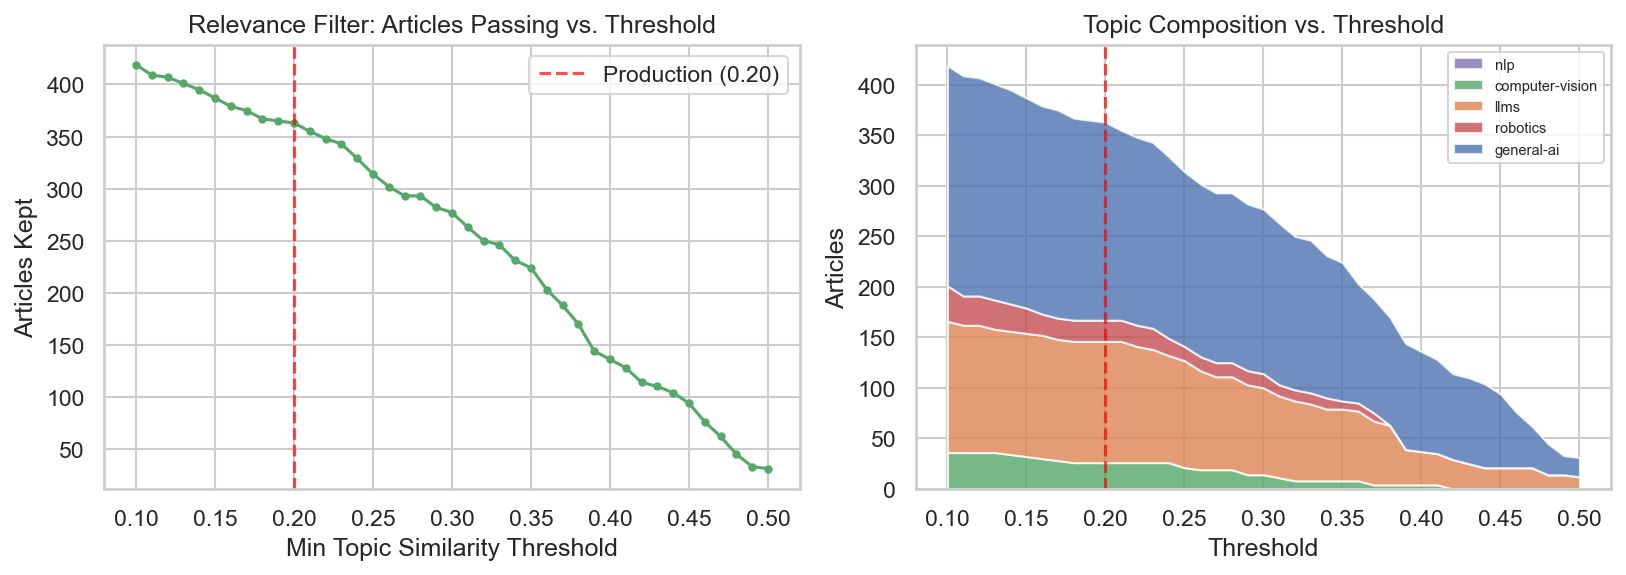

In [5]:
# Relevance threshold sweep
topic_sims = cosine_similarity(article_embeddings, topic_embeddings)
max_topic_sim = topic_sims.max(axis=1)
assigned_topic = np.array(TOPIC_NAMES)[topic_sims.argmax(axis=1)]

rel_thresholds = np.arange(0.10, 0.51, 0.01)
rel_results = []
for t in rel_thresholds:
    mask = max_topic_sim >= t
    topics_kept = pd.Series(assigned_topic[mask]).value_counts().to_dict()
    rel_results.append({
        "threshold": t, "articles_kept": int(mask.sum()),
        "filter_rate": (1 - mask.sum() / len(df)) * 100,
        **{f"n_{topic}": topics_kept.get(topic, 0) for topic in TOPIC_NAMES}
    })

rel_df = pd.DataFrame(rel_results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(rel_df["threshold"], rel_df["articles_kept"], "o-", ms=3, color="#55A868")
ax1.axvline(0.20, color="red", ls="--", alpha=0.7, label="Production (0.20)")
ax1.set(xlabel="Min Topic Similarity Threshold", ylabel="Articles Kept",
        title="Relevance Filter: Articles Passing vs. Threshold")
ax1.legend()

topic_colors_list = ["#8172B3", "#55A868", "#DD8452", "#C44E52", "#4C72B0"]
ax2.stackplot(rel_df["threshold"], *[rel_df[f"n_{t}"] for t in TOPIC_NAMES],
              labels=TOPIC_NAMES, alpha=0.8, colors=topic_colors_list)
ax2.axvline(0.20, color="red", ls="--", alpha=0.7)
ax2.set(xlabel="Threshold", ylabel="Articles",
        title="Topic Composition vs. Threshold")
ax2.legend(loc="upper right", fontsize=7)

plt.tight_layout()
plt.savefig("relevance_threshold.png", bbox_inches="tight")
plt.show()

In [6]:
# Borderline articles near the relevance threshold — what does 0.20 actually decide?
border_mask = (max_topic_sim >= 0.15) & (max_topic_sim <= 0.25)
border_df = df[border_mask][["title", "source", "topic"]].copy()
border_df["max_topic_sim"] = max_topic_sim[border_mask]
border_df["assigned_by_embedding"] = assigned_topic[border_mask]
border_df = border_df.sort_values("max_topic_sim")
border_df[["title", "max_topic_sim", "assigned_by_embedding"]].head(15)

,title,max_topic_sim,assigned_by_embedding
146,Garmin InReach Mini 3 Plus Satellite Messenger...,0.151028,robotics
40,Garmin InReach Mini 3 Plus Satellite Messenger...,0.151028,robotics
15,Acer Promo Codes and Deals: Save 40% on Bundles,0.155916,robotics
121,Acer Promo Codes and Deals: Save 40% on Bundles,0.155916,robotics
20,10 Things You Can Do While Waiting in the TSA ...,0.155931,general-ai
126,10 Things You Can Do While Waiting in the TSA ...,0.155931,general-ai
115,"The Best Samsung Phones of 2026, Tested and Re...",0.158178,computer-vision
9,"The Best Samsung Phones of 2026, Tested and Re...",0.158178,computer-vision
42,Layla Sleep Coupon: Save Up to $600 in March 2026,0.164579,llms
148,Layla Sleep Coupon: Save Up to $600 in March 2026,0.164579,llms


## 2. Embedding Space Visualization

We project the 1536-dimensional article embeddings to 2D using UMAP (cosine metric) to assess whether topic assignments form coherent clusters. Good separation would validate the embedding-based classification approach.

/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


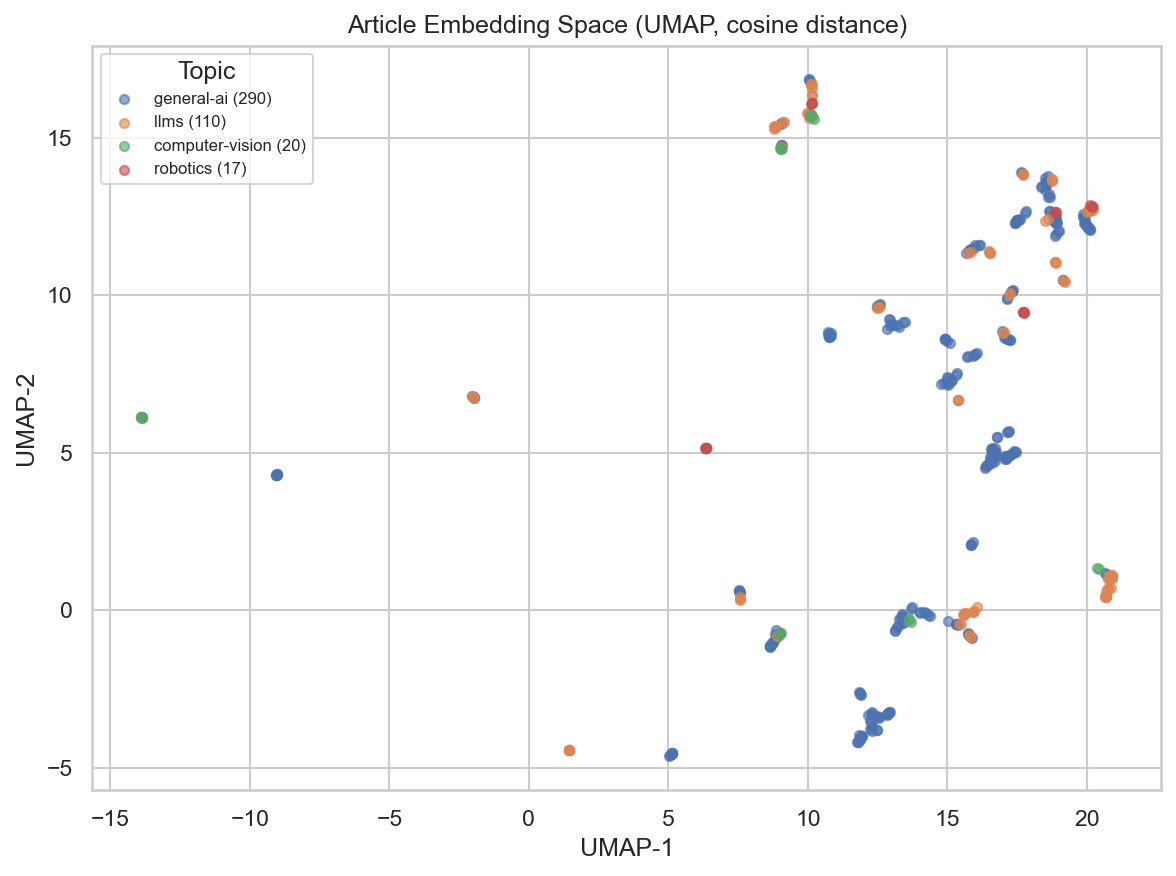

In [7]:
from umap import UMAP

reducer = UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=42)
embedding_2d = reducer.fit_transform(article_embeddings)

topic_colors = {"general-ai": "#4C72B0", "llms": "#DD8452",
                "computer-vision": "#55A868", "robotics": "#C44E52",
                "nlp": "#8172B3"}

fig, ax = plt.subplots(figsize=(8, 6))
for topic in df["topic"].unique():
    mask = df["topic"] == topic
    ax.scatter(embedding_2d[mask, 0], embedding_2d[mask, 1],
               label=f"{topic} ({mask.sum()})", alpha=0.6, s=20,
               c=topic_colors.get(topic, "gray"))

ax.set(title="Article Embedding Space (UMAP, cosine distance)",
       xlabel="UMAP-1", ylabel="UMAP-2")
ax.legend(title="Topic", fontsize=8)
plt.tight_layout()
plt.savefig("umap_topics.png", bbox_inches="tight")
plt.show()

In [8]:
from sklearn.metrics import silhouette_score, silhouette_samples

sil = silhouette_score(article_embeddings, df["topic"], metric="cosine")
print(f"Overall Silhouette Score (cosine): {sil:.3f}\n")

sil_samples = silhouette_samples(article_embeddings, df["topic"], metric="cosine")
print("Per-topic silhouette scores:")
for topic in sorted(df["topic"].unique()):
    mask = df["topic"] == topic
    print(f"  {topic:20s}: {sil_samples[mask].mean():.3f}  (n={mask.sum()})")

Overall Silhouette Score (cosine): 0.029

Per-topic silhouette scores:
  computer-vision     : 0.120  (n=20)
  general-ai          : 0.002  (n=290)
  llms                : 0.065  (n=110)
  robotics            : 0.145  (n=17)


## 3. Source Quality Analysis

Which RSS feeds deliver the most signal? We measure each source's volume, topic diversity, and relevance quality.

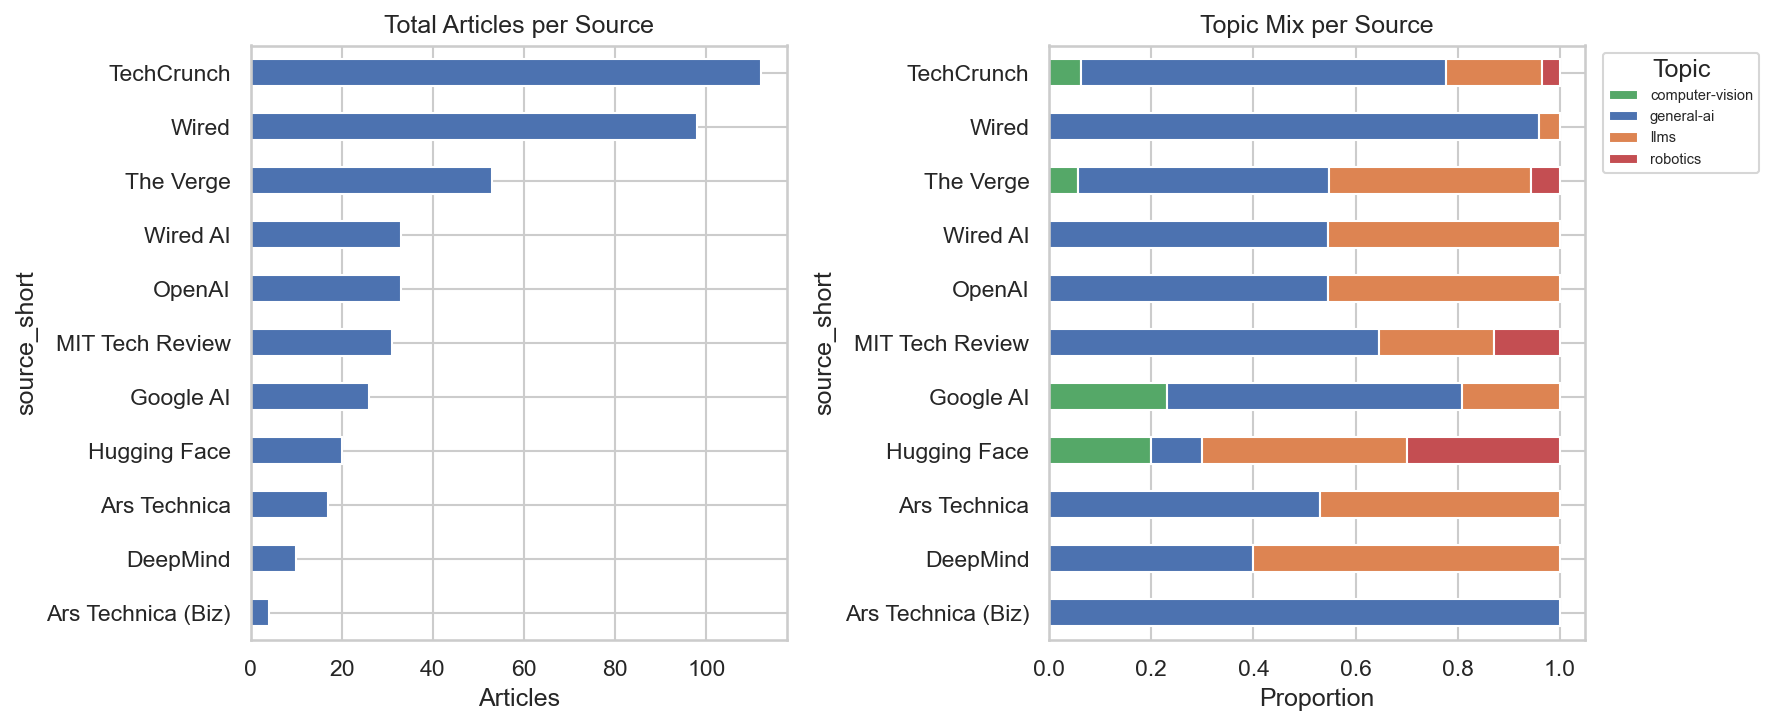

In [9]:
# Clean up source names for readability
source_map = {
    "AI News & Artificial Intelligence | TechCrunch": "TechCrunch",
    "WIRED": "Wired", "Feed: Artificial Intelligence Latest": "Wired AI",
    "AI | The Verge": "The Verge", "OpenAI News": "OpenAI",
    "Artificial intelligence – MIT Technology Review": "MIT Tech Review",
    "AI": "Google AI", "Hugging Face - Blog": "Hugging Face",
    "Artificial Intelligence - Ars Technica": "Ars Technica",
    "Google DeepMind News": "DeepMind",
    "Biz & IT - Ars Technica": "Ars Technica (Biz)",
    "VentureBeat": "VentureBeat",
}
df["source_short"] = df["source"].map(source_map).fillna(df["source"])

# Add relevance scores to df
df["max_topic_sim"] = max_topic_sim
median_sim = np.median(max_topic_sim)
df["high_relevance"] = max_topic_sim > median_sim

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: articles per source
source_counts = df["source_short"].value_counts()
source_counts.sort_values().plot.barh(ax=ax1, color="#4C72B0")
ax1.set(xlabel="Articles", title="Total Articles per Source")

# Right: topic mix per source
ct = pd.crosstab(df["source_short"], df["topic"])
ct_pct = ct.div(ct.sum(axis=1), axis=0)
ct_pct.loc[source_counts.sort_values().index].plot.barh(
    stacked=True, ax=ax2,
    color=[topic_colors.get(t, "gray") for t in ct_pct.columns])
ax2.set(xlabel="Proportion", title="Topic Mix per Source")
ax2.legend(title="Topic", fontsize=7, bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.savefig("source_quality.png", bbox_inches="tight")
plt.show()

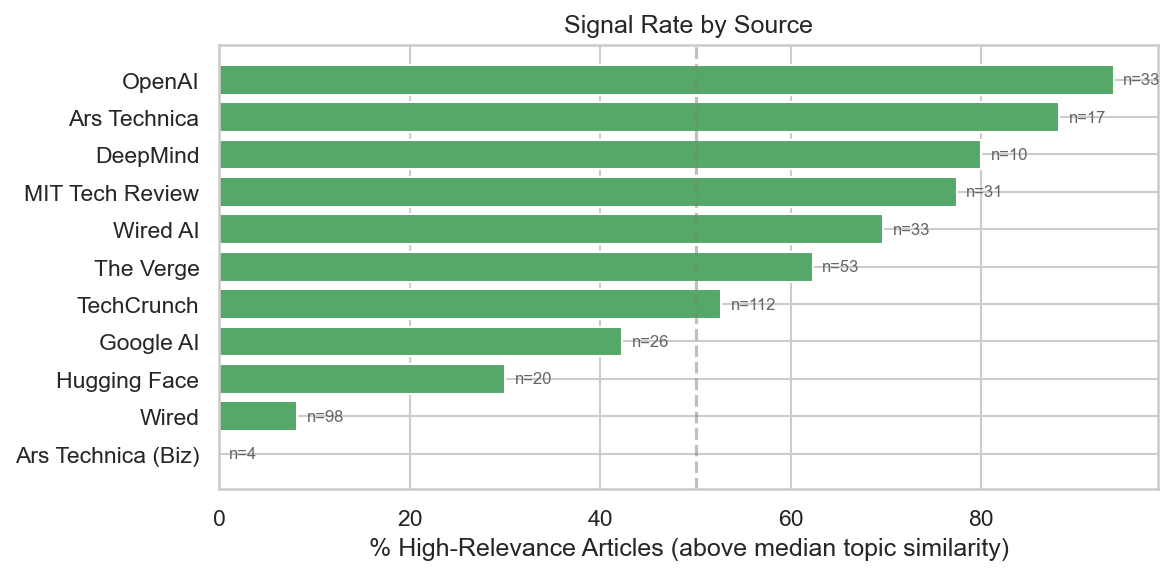

In [10]:
# Signal-to-noise: % of high-relevance articles per source
snr = df.groupby("source_short").agg(
    total=("id", "count"),
    high_rel=("high_relevance", "sum"),
).assign(signal_rate=lambda x: (x["high_rel"] / x["total"] * 100).round(1))
snr = snr.sort_values("signal_rate", ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(snr.index, snr["signal_rate"], color="#55A868")
ax.axvline(50, ls="--", color="gray", alpha=0.5)
ax.set(xlabel="% High-Relevance Articles (above median topic similarity)",
       title="Signal Rate by Source")
for bar, total in zip(bars, snr["total"]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f"n={total}", va="center", fontsize=8, color="#666")
plt.tight_layout()
plt.savefig("source_signal.png", bbox_inches="tight")
plt.show()

## 4. Pipeline Funnel Analysis

Tracking article volume through each pipeline stage across runs: fetched → after dedup → after relevance filter.

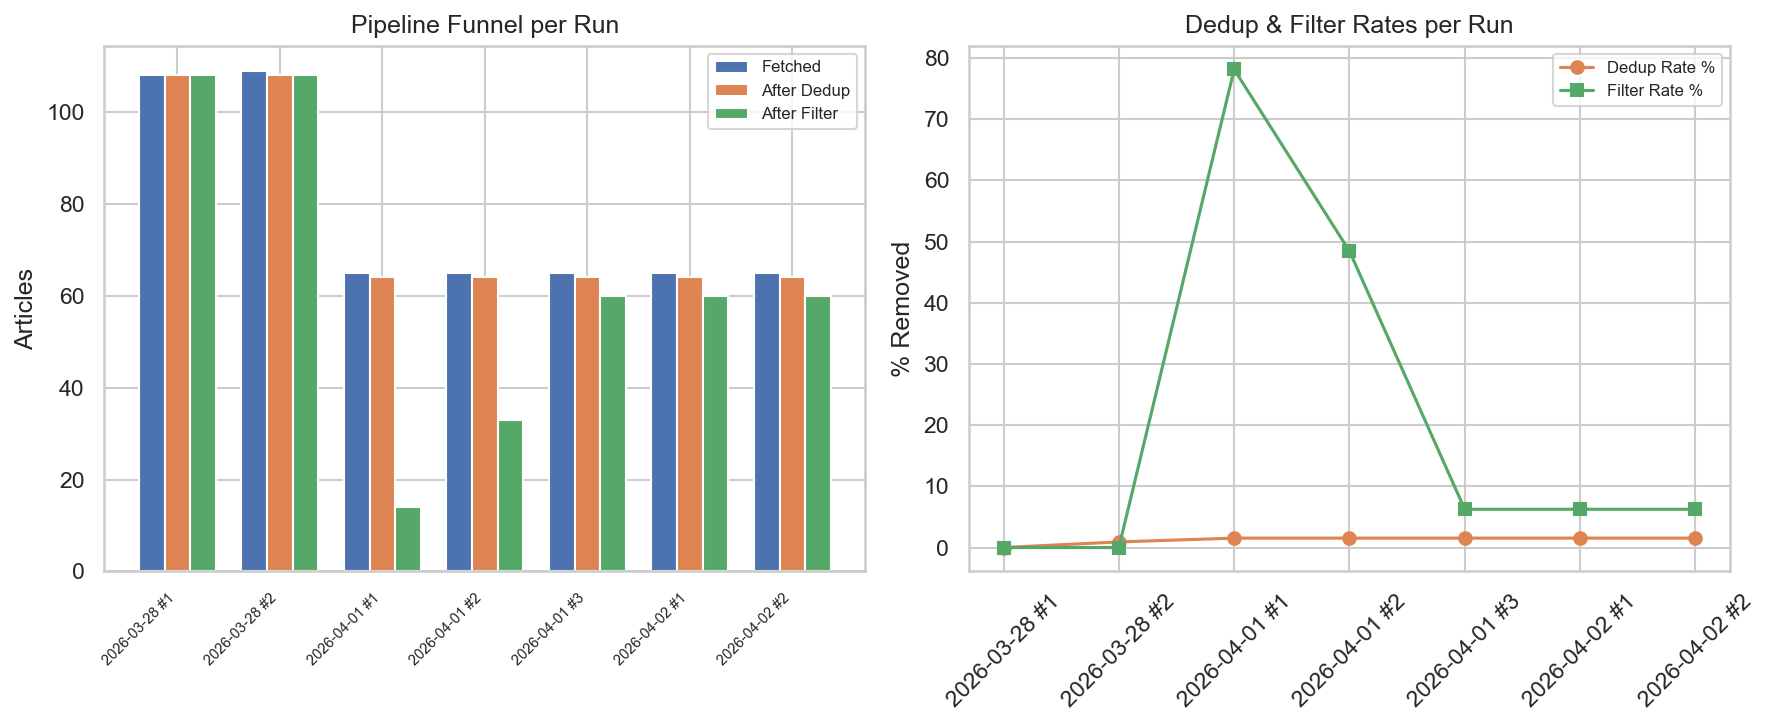

In [11]:
runs_clean = runs.copy()
runs_clean["run_label"] = (runs_clean["run_date"].astype(str) + " #" +
    runs_clean.groupby("run_date").cumcount().add(1).astype(str))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: funnel bar chart
x = np.arange(len(runs_clean))
width = 0.25
ax1.bar(x - width, runs_clean["articles_fetched"], width,
        label="Fetched", color="#4C72B0")
ax1.bar(x, runs_clean["articles_after_dedup"], width,
        label="After Dedup", color="#DD8452")
ax1.bar(x + width, runs_clean["articles_curated"], width,
        label="After Filter", color="#55A868")
ax1.set_xticks(x)
ax1.set_xticklabels(runs_clean["run_label"], rotation=45, ha="right", fontsize=7)
ax1.set(ylabel="Articles", title="Pipeline Funnel per Run")
ax1.legend(fontsize=8)

# Right: dedup and filter rates over time
runs_clean["dedup_rate"] = (1 - runs_clean["articles_after_dedup"] /
                             runs_clean["articles_fetched"]) * 100
runs_clean["filter_rate"] = np.where(
    runs_clean["articles_after_dedup"] > 0,
    (1 - runs_clean["articles_curated"] / runs_clean["articles_after_dedup"]) * 100,
    0)
ax2.plot(runs_clean["run_label"], runs_clean["dedup_rate"], "o-",
         label="Dedup Rate %", color="#DD8452")
ax2.plot(runs_clean["run_label"], runs_clean["filter_rate"], "s-",
         label="Filter Rate %", color="#55A868")
ax2.set(ylabel="% Removed", title="Dedup & Filter Rates per Run")
ax2.tick_params(axis="x", rotation=45)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig("funnel.png", bbox_inches="tight")
plt.show()

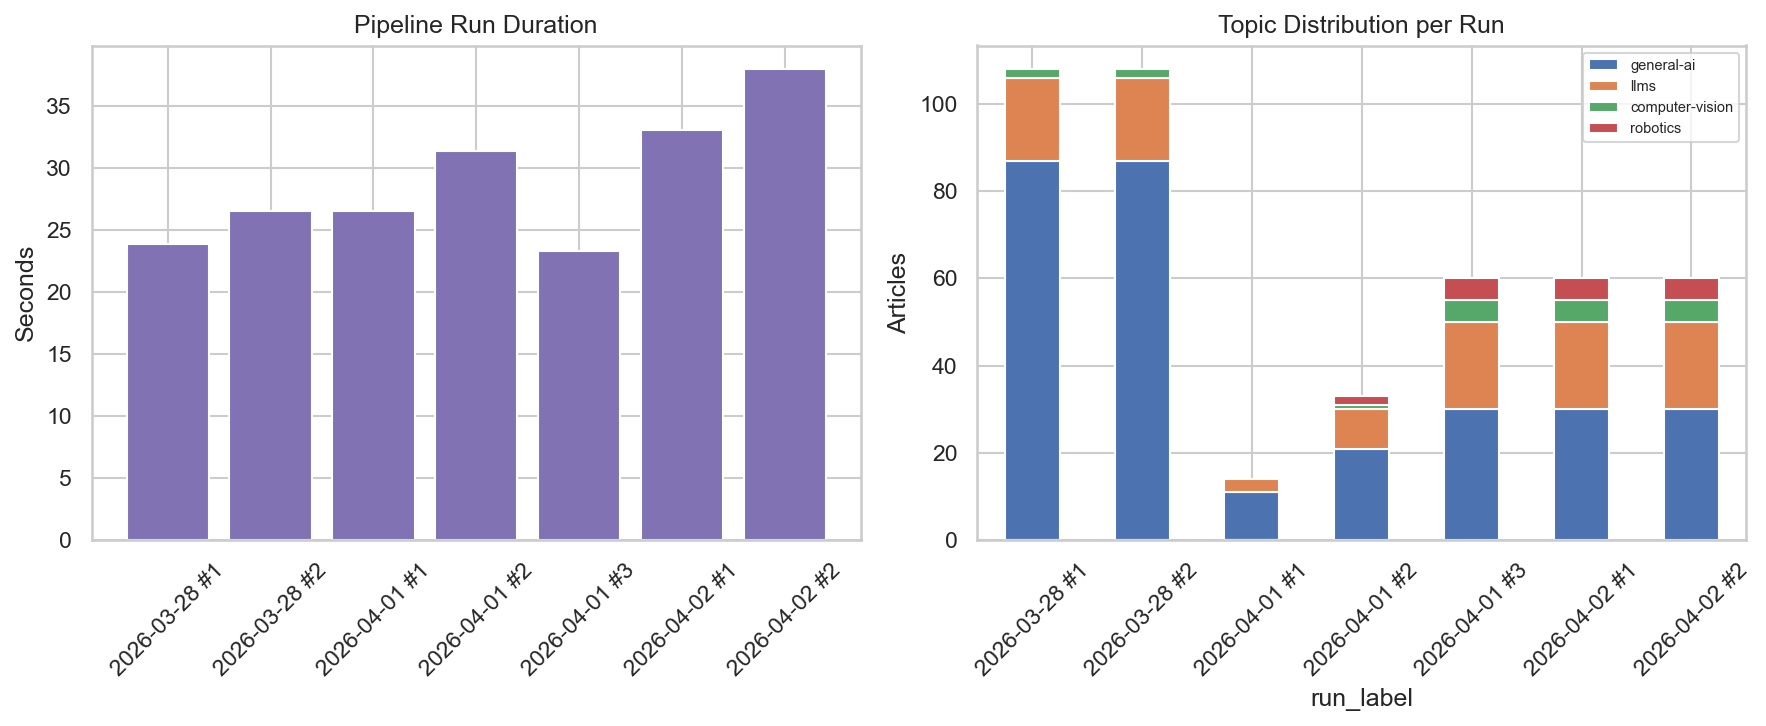

In [12]:
# Run duration and topic evolution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(runs_clean["run_label"], runs_clean["run_duration_seconds"], color="#8172B3")
ax1.set(ylabel="Seconds", title="Pipeline Run Duration")
ax1.tick_params(axis="x", rotation=45)

topic_data = pd.DataFrame(runs_clean["topics"].tolist(), index=runs_clean["run_label"])
topic_data = topic_data.fillna(0)
topic_data.plot.bar(stacked=True, ax=ax2,
    color=[topic_colors.get(t, "gray") for t in topic_data.columns])
ax2.set(ylabel="Articles", title="Topic Distribution per Run")
ax2.legend(fontsize=7)
ax2.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Key Findings

1. **Dedup threshold (0.85) is well-calibrated.** The pairwise similarity distribution shows a clear gap between unrelated articles (0.1–0.5) and true duplicates (0.85+). The threshold sits cleanly in this valley.

2. **Relevance threshold (0.20) is appropriately permissive.** Raising it above 0.30 starts killing minority topics (robotics, computer-vision). At 0.20, only clearly non-AI content is filtered (movie reviews, earplug listicles).

3. **The NLP topic receives zero articles.** Its description ("natural language processing, text generation, language models...") overlaps too heavily with LLMs. Recommendation: merge NLP into LLMs or rewrite the topic description to be more distinct.

4. **`general-ai` is a catch-all.** It captures ~66% of articles — anything that doesn't strongly match a specific topic lands here. Consider splitting into sub-categories (policy, industry, research) for better signal.

5. **Source concentration risk.** TechCrunch and Wired account for a disproportionate share of articles. Lab blogs (OpenAI, DeepMind, Hugging Face) are lower volume but higher signal-to-noise.

6. **Pipeline runtime is stable** at 23–38 seconds, dominated by the GPT-4o curation API call. Embedding and dedup are negligible.

### Next Steps
- Persist article embeddings in the pipeline to avoid re-embedding costs during analysis
- Rewrite NLP topic description or merge with LLMs
- Add source diversity weighting to the relevance filter
- Split `general-ai` into more specific sub-topics as the dataset grows